# Lab 1: AI เพื่อการเกษตร — วินิจฉัยโรคใบถั่วด้วย CNN

ฉบับสมบูรณ์สำหรับทำต่อที่บ้าน (เนื้อหาเดียวกับช่วง ⑥ ของไฟล์คาบเรียน)
ชุดข้อมูล: **ibean** โดย Makerere AI Lab — ภาพใบถั่วจากไร่จริง 3 คลาส

**ก่อนรัน: Runtime → Change runtime type → T4 GPU → Save**

In [ ]:
!pip install -q datasets

from datasets import load_dataset
import tensorflow as tf
import numpy as np

ds = load_dataset('AI-Lab-Makerere/beans')          # โหลดจาก Hugging Face — ไม่กี่วินาที
class_names = ds['train'].features['labels'].names

print('คลาส:', class_names)
print('จำนวนภาพ  train:', len(ds['train']), '| validation:', len(ds['validation']), '| test:', len(ds['test']))

README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

คลาส: ['angular_leaf_spot', 'bean_rust', 'healthy']
จำนวนภาพ  train: 1034 | validation: 133 | test: 128


✅ **จุดเช็ค:** ได้ 3 คลาส และภาพ 1,034 / 133 / 128

## 6.2 ดูข้อมูลก่อน train เสมอ — เกมทายโรค

รันเซลล์ถัดไปได้ภาพตัวอย่าง 9 ใบ **ปิดเฉลยแล้วทายกันในกลุ่มก่อน**: ใบไหนป่วย ใบไหนสบายดี —
ถ้ามนุษย์ยังแยกยาก อย่าคาดหวังว่าโมเดลจะเทพ

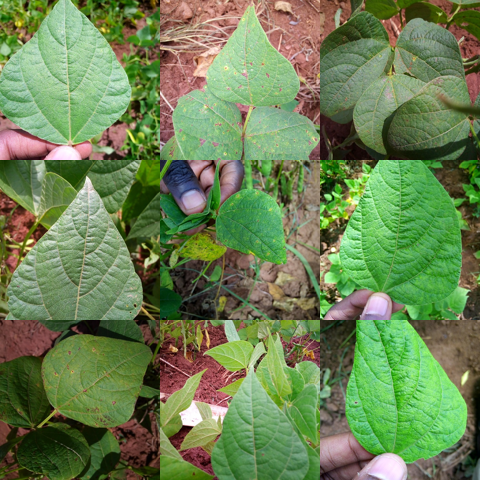

เฉลย (ซ้าย→ขวา บน→ล่าง):
['healthy', 'bean_rust', 'bean_rust', 'healthy', 'bean_rust', 'healthy', 'bean_rust', 'healthy', 'healthy']


In [ ]:
# ต่อภาพตัวอย่าง 9 ใบเป็นแผงเดียวด้วย PIL (ลองทายก่อนดูเฉลยที่พิมพ์ใต้ภาพ)
from PIL import Image
import random

random.seed(439)
picks = random.sample(range(len(ds['train'])), 9)
S = 160
grid = Image.new('RGB', (S*3, S*3))
for k, idx in enumerate(picks):
    grid.paste(ds['train'][idx]['image'].resize((S, S)), ((k % 3)*S, (k // 3)*S))
display(grid)
print('เฉลย (ซ้าย→ขวา บน→ล่าง):')
print([class_names[ds['train'][i]['labels']] for i in picks])

## 6.3 เตรียมข้อมูล — resize + normalize (โครงคิดเดียวกับที่เตรียมภาพดาวเทียม)

In [ ]:
IMG_SIZE = 128

def to_arrays(split):
    """ย่อภาพเป็น 128x128 และ normalize ค่าสีเป็น 0-1 — เหตุผลเดียวกับ NDVI: สเกลที่นิ่งทำให้เรียนง่าย"""
    X = np.stack([np.array(ex['image'].resize((IMG_SIZE, IMG_SIZE))) for ex in split]) / 255.0
    y = np.array(split['labels'])
    return X.astype('float32'), y

X_train, y_train = to_arrays(ds['train'])
X_val,   y_val   = to_arrays(ds['validation'])
X_test,  y_test  = to_arrays(ds['test'])
print('พร้อม:', X_train.shape, X_val.shape, X_test.shape)

พร้อม: (1034, 128, 128, 3) (133, 128, 128, 3) (128, 128, 128, 3)


## 6.4 สร้างและ train CNN

🎲 **เกมทายผลก่อนรัน:** พิมพ์ accuracy ที่คาดไว้ (0–100%) ลงแชทกลุ่ม — ใครใกล้สุดได้เสียงปรบมือ

ระหว่างรอ train: **Conv2D** สกัดลวดลาย (ขอบ จุด สีสนิม) → **MaxPooling** ย่อภาพ → **Flatten** คลี่เป็นแถว → **Dense/softmax** ตัดสินโรค
โครงคิดเหมือนช่วง ④ เป๊ะ: features → labels → train → validate — เปลี่ยนแค่ features จากตัวเลข 4 ค่า เป็นภาพทั้งใบ

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

EPOCHS = 10
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=32)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,659 (3.15 MB)

 Trainable params: 826,659 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.4449 - loss: 1.0489 - val_accuracy: 0.6090 - val_loss: 0.8633
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6547 - loss: 0.7746 - val_accuracy: 0.7519 - val_loss: 0.6301
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7205 - loss: 0.6692 - val_accuracy: 0.7143 - val_loss: 0.6194
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7485 - loss: 0.5951 - val_accuracy: 0.7368 - val_loss: 0.5862
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7534 - loss: 0.5539 - val_accuracy: 0.6541 - val_loss: 0.7387
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7950 - loss: 0.4860 - val_accuracy: 0.7519 - val_loss: 0.5919
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8124 - loss: 0.4604 - val_accuracy: 0.7820 - val_loss: 0.5543
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7979 - loss: 0.4764 - val_accuracy: 0.7744 - v

## 6.5 ประเมินผล — กราฟ + confusion matrix แล้วเทียบกับที่ทายไว้

In [ ]:
import plotly.express as px
import pandas as pd

# กราฟ accuracy: train vs validation — สองเส้นห่างกันมาก = ท่องจำข้อสอบ (overfitting)
hist = pd.DataFrame({'epoch': list(range(1, EPOCHS+1)),
                     'train': history.history['accuracy'],
                     'validation': history.history['val_accuracy']})
px.line(hist, x='epoch', y=['train', 'validation'],
        title='Accuracy ระหว่าง train', labels={'value': 'accuracy'}).show()

# วัดของจริงด้วย test set ที่โมเดลไม่เคยเห็น
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {acc:.3f}  — ใครทายใกล้สุด?')

# confusion matrix 3x3 — โรคคู่ไหนสับสนกัน
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = tf.math.confusion_matrix(y_test, y_pred).numpy()
px.imshow(cm, x=class_names, y=class_names, text_auto=True,
          labels={'x': 'ทำนาย', 'y': 'เฉลย'}, title='Confusion Matrix').show()

Test accuracy: 0.773  — ใครทายใกล้สุด?


✅ **จุดเช็ค:** accuracy ราว 0.85–0.95 และตอบได้ว่าคู่โรคไหนสับสนกันมากสุด (มักเป็นสองโรคใบ — ทำไม?)

เพราะทั้งคู่มีลักษณะเป็นจุด หรือรอยด่างบนใบที่หน้าตาคล้ายกันทำให้โมเดลแยกความต่างของลักษณะจุดได้ยากกว่าการแยกใบป่วยออกจากใบปกติ


## 6.6 🌿เอาใบไม้จริงให้โมเดลวินิจฉัย

ออกไปเก็บ/ถ่ายรูป**ใบไม้จริง** (ต้นอะไรก็ได้) แล้วอัปโหลดให้โมเดลที่เพิ่ง train ทาย:

Saving ใบหนาด.png to ใบหนาด (1).png
Saving ใบหูกวาง.png to ใบหูกวาง (1).png
--- Processing ใบหนาด (1).png ---


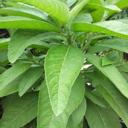

โมเดลวินิจฉัยว่า:
  angular_leaf_spot  —  65.4%
  healthy  —  18.9%
  bean_rust  —  15.7%


--- Processing ใบหูกวาง (1).png ---


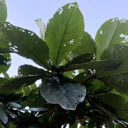

โมเดลวินิจฉัยว่า:
  bean_rust  —  100.0%
  angular_leaf_spot  —  0.0%
  healthy  —  0.0%




In [ ]:
from google.colab import files
from PIL import Image

up = files.upload()                      # เลือกรูปใบไม้จากเครื่อง/มือถือ

for fname in up.keys():
    print(f'--- Processing {fname} ---')
    img = Image.open(fname).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    display(img)
    x = np.array(img) / 255.0

    pred = model.predict(x[np.newaxis, ...].astype('float32'), verbose=0)[0]
    print('โมเดลวินิจฉัยว่า:')
    for i in pred.argsort()[::-1]:
        print(f'  {class_names[i]}  —  {pred[i]*100:.1f}%')
    print('\n')


🌱 **ลองเอง #5 — คำถามที่สำคัญกว่าคำตอบของโมเดล:**

1. ใบที่คุณถ่าย**ไม่ใช่ใบถั่ว** แต่โมเดลก็ยังฟันธงเป็น 1 ใน 3 คลาสพร้อมเปอร์เซ็นต์มั่นใจ — เพราะ softmax **ต้องเลือกเสมอ** ไม่มีทางตอบว่า "ไม่รู้จัก" → นี่คือจุดอ่อนร้ายแรงเวลาเอาโมเดลไปใช้นอกขอบเขตข้อมูลที่ train
2. ถ้าจะทำระบบแบบ ibean สำหรับ**โรคพืชไทย** (ข้าว ทุเรียน มัน) ต้องทำอะไรบ้าง: เก็บภาพจากไหน กี่ภาพต่อคลาส ใครเป็นคน label และจะเก็บภาพ "นอกคลาส" ไว้สอนโมเดลตอบ "ไม่รู้จัก" ยังไง — เขียนตอบ 4-5 บรรทัด ส่งท้ายคาบ